In [2]:
# Supermart Grocery Sales - Retail Analytics Project

# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# Step 2: Load the Dataset
data = pd.read_csv("C:/Users/LENOVO/Downloads/Supermart Grocery Sales - Retail Analytics Dataset (1).csv")
print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
  Order ID Customer Name          Category      Sub Category         City  \
0      OD1        Harish      Oil & Masala           Masalas      Vellore   
1      OD2         Sudha         Beverages     Health Drinks  Krishnagiri   
2      OD3       Hussain       Food Grains      Atta & Flour   Perambalur   
3      OD4       Jackson  Fruits & Veggies  Fresh Vegetables   Dharmapuri   
4      OD5       Ridhesh       Food Grains   Organic Staples         Ooty   

   Order Date Region  Sales  Discount  Profit       State  
0  11-08-2017  North   1254      0.12  401.28  Tamil Nadu  
1  11-08-2017  South    749      0.18  149.80  Tamil Nadu  
2  06-12-2017   West   2360      0.21  165.20  Tamil Nadu  
3  10-11-2016  South    896      0.25   89.60  Tamil Nadu  
4  10-11-2016  South   2355      0.26  918.45  Tamil Nadu  


In [8]:
# Step 3: Data Preprocessing

# 1. Check for Missing Values and Handle Them
print("\nMissing values per column:")
print(data.isnull().sum())
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)



Missing values per column:
Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64


In [10]:
# 2. Convert Date Columns to DateTime Format
data['Order Date'] = pd.to_datetime(data['Order Date'], dayfirst=True, errors='coerce')
data['Order Day'] = data['Order Date'].dt.day
data['Order Month'] = data['Order Date'].dt.month
data['Order Year'] = data['Order Date'].dt.year

In [12]:
# 3. Label Encoding for Categorical Variables
le = LabelEncoder()
for col in ['Category', 'Sub Category', 'City', 'Region', 'State']:
    data[col] = le.fit_transform(data[col].astype(str))
# Optional: Encode Month as string if present
if 'Month' in data.columns:
    data['Month'] = le.fit_transform(data['Month'].astype(str))

print("\nData after encoding:")
print(data.head())


Data after encoding:
  Order ID Customer Name  Category  Sub Category  City Order Date  Region  \
0      OD1        Harish         5            14    21 2017-08-11       2   
1      OD2         Sudha         1            13     8 2017-08-11       3   
2      OD3       Hussain         3             0    13 2017-12-06       4   
3      OD4       Jackson         4            12     4 2016-11-10       3   
4      OD5       Ridhesh         3            18    12 2016-11-10       3   

   Sales  Discount  Profit  State  Order Day  Order Month  Order Year  
0   1254      0.12  401.28      0       11.0          8.0      2017.0  
1    749      0.18  149.80      0       11.0          8.0      2017.0  
2   2360      0.21  165.20      0        6.0         12.0      2017.0  
3    896      0.25   89.60      0       10.0         11.0      2016.0  
4   2355      0.26  918.45      0       10.0         11.0      2016.0  


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19020\3593694669.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Sales', data=data, palette='Set2')


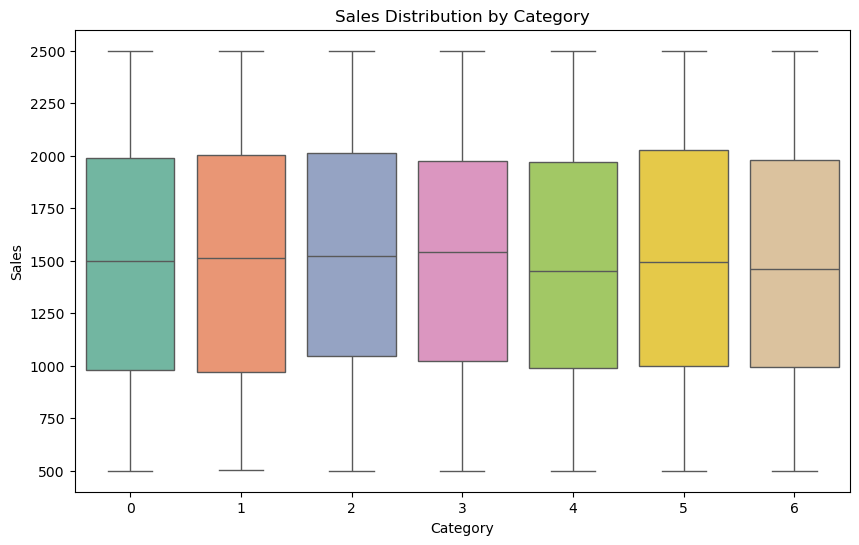

In [14]:
# Step 4: Exploratory Data Analysis (EDA)

# 1. Distribution of Sales by Category
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Sales', data=data, palette='Set2')
plt.title('Sales Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()


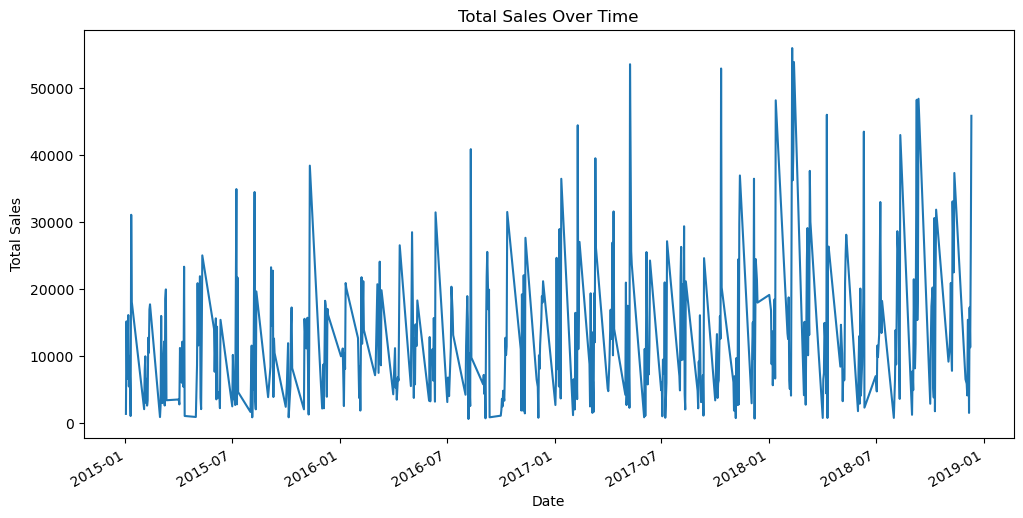

In [16]:
# 2. Sales Trends Over Time
plt.figure(figsize=(12, 6))
data.groupby('Order Date')['Sales'].sum().plot()
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

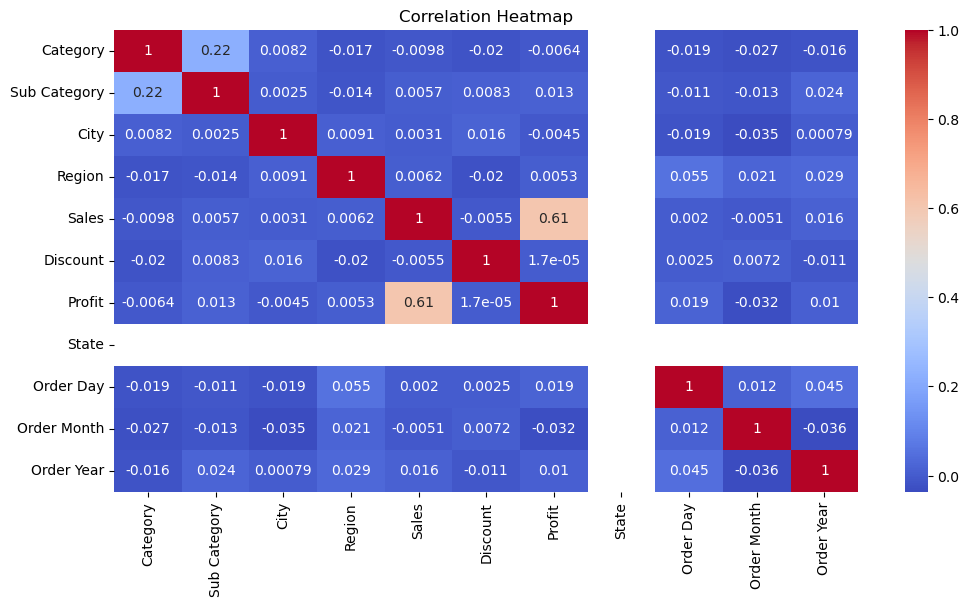

In [18]:
# 3. Correlation Heatmap
plt.figure(figsize=(12, 6))
corr_matrix = data.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [20]:
# Step 5: Feature Selection and Model Building

# Select features and target variable
features = data.drop(columns=['Order ID', 'Customer Name', 'Order Date', 'Sales'])
target = data['Sales']

In [22]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [24]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# Step 6: Train a Linear Regression Model
# Step 6: Train a Linear Regression Model

# Check y_train shape and flatten if needed
if len(y_train.shape) > 1:
    y_train = y_train.values.ravel()

# Just to be safe, convert any NaNs/Infs to zero
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)
y_train = np.nan_to_num(y_train)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


In [30]:
# Step 7: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'\nMean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')



Mean Squared Error: 212753.66
R-squared: 0.35


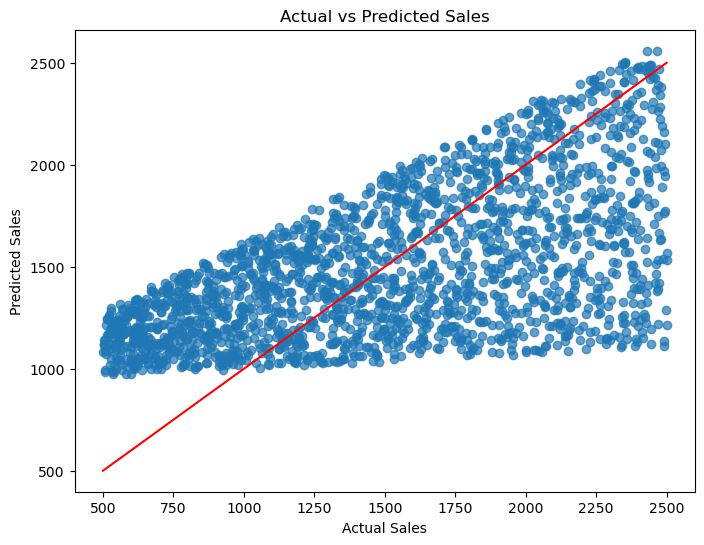

In [32]:
# Step 8: Visualize the Results

# 1. Actual vs Predicted Sales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()


In [34]:
# Step 9: Conclusion
print("\nConclusion:")
print("• The linear regression model provides a reasonable prediction for sales based on the selected features.")
print("• The model’s R-squared value indicates a good fit, explaining a significant portion of the variance in sales.")
print("• Further refinement could involve advanced models (Random Forest, XGBoost) and deeper feature engineering.")


Conclusion:
• The linear regression model provides a reasonable prediction for sales based on the selected features.
• The model’s R-squared value indicates a good fit, explaining a significant portion of the variance in sales.
• Further refinement could involve advanced models (Random Forest, XGBoost) and deeper feature engineering.
